### <table>
<tr>
    <td width=10%><img src="./img/logo_lri.jpg"></td>
    <td width=30%><img src="./img/medi-chal_logo.png" height=15%></img></td>
</tr>

</table>

<br/><br/><div id="top"></div>

<center><a style="font-size: 40pt; font-weight: bold">
    Être ou ne pas être ?
</a></center>
<br/>
<center><a style="font-size: 22pt; font-weight: bold">
    Un problème de classification binaire sur des données médicales artificelles
<br/>

---

# Membres du groupe



* ETTAYEB, Nour
* FABREGA, Isabel
* BENOSMANE, Lydia

# Présentation du challenge

## La question principale de ce challenge est :

* Comment prédire la survie d'un·e patient·e compte tenu de son dossier médical ?
    
* Plus précisément, vous devrez prédire la survie des patient·e·s pendant leur séjour à l'hôpital

Chaque jour, le personnel soignant collecte de nombreuses informations sur les patient·e·s en posant des questions et en utilisant des outils de mesure (stéthoscope, analyse de sang, capteurs, etc.). Ces données sont très utiles pour surveiller l'état de santé, diagnostiquer et choisir les traitements.

Elles peuvent également être utilisées pour l'analyse statistique prédictive.

## Données

L'ensemble de données contient des informations sur 80'000 patient·e·s, représentés par des variables (descripteurs) catégorielles, binaires et numériques. Ces variables sont, par exemple, l'âge, le sexe, l'origine ethnique, l'état matrimonial, ainsi que des données médicales telles que la tension artérielle ou le taux de glucose. Il y a un total de 342 variables.

La classe (étiquette ou label) à prédire est une variable binaire indiquant si la·le patient·e est décédé·e ou non pendant son séjour à l'hôpital. Heureusement, la plupart survivent :

![](img/tobe.png)

## Tâche

La tâche consiste à créer un modèle capable d'apprendre à partir des données et de faire des prédictions (apprentissage supervisé). Chaque instance (patient·e) possède une variable indiquant si elle·il est décédé·e ou non pendant son séjour à l'hôpital.

Références et crédit :

Isabelle Guyon, Kristin Bennett, Andrew Yale, Adrien Pavao, Thomas Gerspacher

## Instructions

Le but de ce projet est de travailler sur un challenge de prédiction de la mortalité.

## Évaluation du projet

* **4 points** pour la partie compréhension et analyse exploratoire
    
* **4 points** pour un code propre et bien documenté

* **4 points** pour la qualité du modèle (sélection du modèle, sélection des hyperparamètres)

* **4 points** pour une bonne évaluation des performances du modèle

* **4 points** pour la qualité de la présentation orale

* **1 point bonus** pour l'équipe gagnante du challenge

### FAQ

* Soumettre uniquement le notebook sur eCampus

* La partie texte (explications, résultats, problèmes, sans le code) ne doit pas dépasser 3 pages A4 11pt (< 1500 mots)

# Challenge

Module requis : `imblearn` (à installer avec `conda`)

`conda install -c conda-forge imbalanced-learn`

In [148]:
import platform
from datetime import datetime
from pathlib import Path

import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn import (
    decomposition,
    discriminant_analysis,
    ensemble,
    linear_model,
    metrics,
    model_selection,
    naive_bayes,
    pipeline,
    preprocessing,
    svm,
    tree,
    neighbors
)

In [149]:
if platform.system() == "Darwin":
    %config InlineBackend.figure_format="retina"  # For high DPI display

# Set precision for pd and np (np: suppress also sci notation)
np.set_printoptions(precision=3, suppress=True)
pd.options.display.float_format = "{:,.3g}".format

sns.set_style("darkgrid")
sns.set_context("notebook")

print(pd.__version__)       # 2.0.0
print(sklearn.__version__)  # 1.2.2

2.0.2
1.2.2


## 1. Compréhension du problème

### Expliquez brièvement la tâche avec vos mots

<span style="color:#000099"> 
On désire prédire la survie  ou  non d’un patient donné grâce à l’apprentissage automatique sur des données fournies à propos des patients au sein d’un hôpital.
Nous allons donc réaliser une classification de type binaire puisqu’on veut distinguer 2 classes (les survivants et les non-survivants) 
</span>

### Métrique utilisée

Pourquoi la métrique utilisée ici est la [`sklearn.metrics.balanced_accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html) plutôt que simplement l'[`sklearn.metrics.accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) ?

<span style="color:#000099"> 
L’accuracy consiste à mettre en lumière la proportion des prédictions justes. Cependant si les classes sont déséquilibrées ,l’accuracy est peu informative . Dans notre situation il est précisé dans l’énoncé que la plupart des patients survivent. Il  y a donc un déséquilibre entre les 2 classes survived et died .Par conséquent, il est nécessaire d’utiliser balanced_accuracy pour prendre en compte ce déséquilibre.
</span>

## 2. Chargement des données

In [150]:
DATA = Path(
    "~/ownCloud/EDU/Courses/L2-ISD2/PRACTICALs/Project/public_data"
).expanduser()
DATA = Path("public_data")

PRED_PATH = Path("Submissions")

DROP_VARS = ["ADMITTIME", "DISCHTIME", "SUBJECT_ID", "HADM_ID"]

assert DATA.is_dir()

In [151]:
features = pd.read_csv(
    DATA / "mimic_synthetic_feat.name", header=None
).values.flatten()

labels = pd.read_csv(
    DATA / "mimic_synthetic_label.name", header=None
).values.flatten()

x_df = pd.read_csv(
    DATA / "mimic_synthetic_train.data",
    header=None,
    names=features,
    sep=" ",
)

# Remove variables that are not relevant
x_df.drop(columns=DROP_VARS, inplace=True)

ys = pd.Series(
    pd.read_csv(
        DATA / "mimic_synthetic_train.solution",
        header=None,
        names=labels,
        sep=" ",
    ).values.flatten()
)

In [152]:
print(x_df.shape)
x_df.head(3)

(79999, 337)


,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,Private,ENGL,CATHOLIC,DIVORCED,WHITE,F,21,57.2,109,70.8,...,0,0,0,0,0,0,0,0,0,0
1,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,M,39,79.3,121,96.9,...,0,0,0,0,0,0,0,0,0,1
2,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,M,40,118,175,141,...,0,0,0,0,0,0,0,0,0,0


C'est **l'ensemble d'entrainement**. Cela signifie que vous avez accès aux étiquettes et que vous pouvez l'utiliser comme vous le souhaitez pour préparer votre modèle.

Plus tard, vous ferez en sorte que votre modèle tire des prédictions de **l'ensemble de test** afin de les téléverser sur Codabench (les modalités pour la téléversion seront précisées prochainement sur la page du cours eCampus）et d'obtenir un score sur des données non vues lors de l'entrainement des modèles.

In [153]:
# Load test set
x_test_df = pd.read_csv(
    DATA / "mimic_synthetic_test.data",
    header=None,
    names=features,
    sep=" ",
)

# Remove variables that are not relevant
x_test_df.drop(columns=DROP_VARS, inplace=True)

print(x_test_df.shape)
x_test_df.head(3)

(20001, 337)


,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,Self_Pay,ENGL,OTHER,MARRIED,WHITE,F,18,72.6,113,96.5,...,0,0,0,0,0,0,0,0,0,0
1,Medicare,ENGL,NOT_SPECIFIED,SINGLE,BLACK/AFRICAN_AMERICAN,F,56,66.6,107,83.8,...,0,0,0,0,0,0,0,0,1,0
2,Medicaid,ENGL,CATHOLIC,SINGLE,WHITE,M,32,69.7,103,87.3,...,0,0,0,0,0,0,0,0,0,0


## 3. Analyse exploratoire

#### Types des variables

In [154]:
types = pd.read_csv(DATA / "mimic_synthetic_feat.type", header=None).set_index(
    features
)[0]

types.value_counts()

0
Numerical      226
Binary         107
Categorical      8
Name: count, dtype: int64

#### Distribution de la variable cible

In [155]:
ys.describe()

count   8e+04
mean    0.035
std     0.184
min         0
25%         0
50%         0
75%         0
max         1
dtype: float64

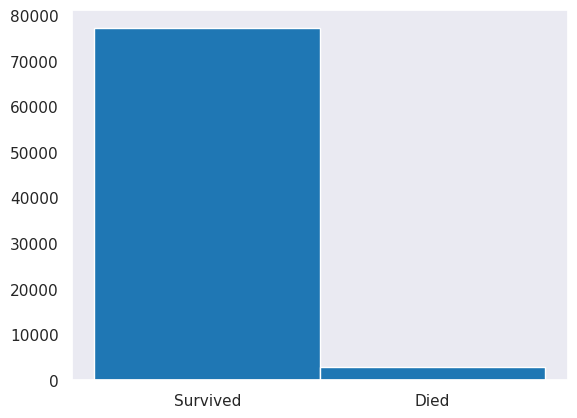

In [156]:
ys.hist(bins=2, grid=False, align="left")
plt.xticks([0, 0.5], ["Survived", "Died"])
# plt.savefig("img/tobe.png", dpi=300)
plt.show()

### Code : Produire les graphiques suivants

* Diagrammes à barres de certaines variables catégorielles (par exemple "LANGUAGE", "MARITAL_STATUS")

* Montrez la corrélation entre certaines variables et la variable cible y

* Un autre graphique ou toute analyse exploratoire à laquelle vous pouvez penser

Exemple

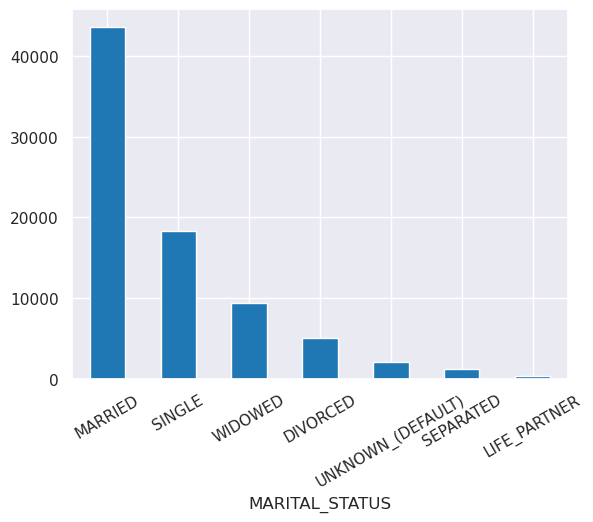

In [157]:
x_marital_cnts = x_df["MARITAL_STATUS"].value_counts()
x_marital_cnts.plot.bar(rot=30)
plt.show()

***TODO: Bar plot of another variable:***

<span style="color:#000099">
   On choisis d'afficher le bar plot des gender.
</span>

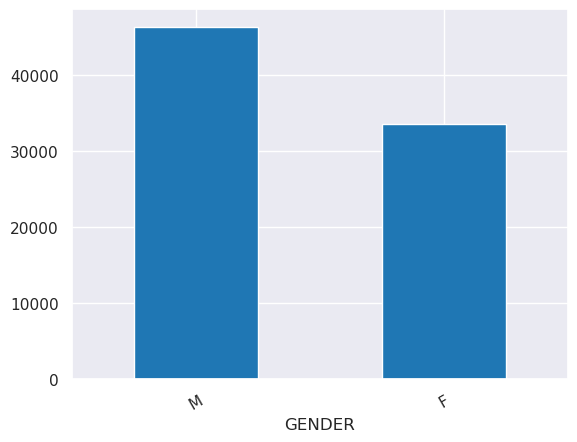

In [158]:
x_gender_cnts = x_df["GENDER"].value_counts()
x_gender_cnts.plot.bar(rot=30)
plt.show()

#### Corrélations

***TODO: Bar plot of the variables most correlated with y***

<span style="color:#000099">
On remarque que certaines données sont de type object, on décide de les encoder grace au labelEncoder
</span>


In [159]:
from sklearn.preprocessing import LabelEncoder
df_string = x_df.select_dtypes(include=['object'])
le = LabelEncoder()
for series_name, series in df_string.items():
    df_string[series_name] = le.fit_transform(series)
df_string.head()

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,ICU
0,3,45,3,0,36,0,3
1,3,45,19,4,36,1,0
2,1,63,3,6,30,1,2
3,2,45,14,2,36,1,0
4,2,45,19,2,35,0,2


In [160]:
df_ys=ys.to_frame() #MERGING YS WITH X_DF
df_ys.columns=["Dead"]
df=pd.concat([df_ys,df_string,x_df], axis=1, join="inner")
df

,Dead,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,ICU,INSURANCE,LANGUAGE,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,0,3,45,3,0,36,0,3,Private,ENGL,...,0,0,0,0,0,0,0,0,0,0
1,0,3,45,19,4,36,1,0,Private,ENGL,...,0,0,0,0,0,0,0,0,0,1
2,0,1,63,3,6,30,1,2,Medicaid,SPAN,...,0,0,0,0,0,0,0,0,0,0
3,0,2,45,14,2,36,1,0,Medicare,ENGL,...,0,0,0,0,0,0,0,0,1,0
4,0,2,45,19,2,35,0,2,Medicare,ENGL,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79994,0,2,45,14,5,36,0,1,Medicare,ENGL,...,0,0,0,0,0,0,0,0,1,0
79995,0,1,45,10,2,36,0,4,Medicaid,ENGL,...,0,0,0,0,0,1,0,0,0,0
79996,0,3,45,14,3,36,0,3,Private,ENGL,...,0,0,0,0,0,0,0,0,0,0
79997,0,0,45,3,2,13,1,4,Government,ENGL,...,0,0,0,0,0,0,0,0,1,0


<ul style="color:#000099">
On concatène les tables de données  :
<li> df_string (catégorie encodé par des entiers)</li>
<li> x_df ( les données initiales fournies ) , remarque : on exclue les catégories puisqu'elles sont gérées maintenant comme des données numériques (df_string)</li>
<li> et df_ys ( = colonne de dead )</li>
</ul>


In [161]:
df_numeric = df.select_dtypes(exclude=['object']) 
df_corr=df_numeric.corr()

<span style="color:#000099">
On affiche les résultats avec des barres horizontales (barh)  :
</span>


<Axes: >

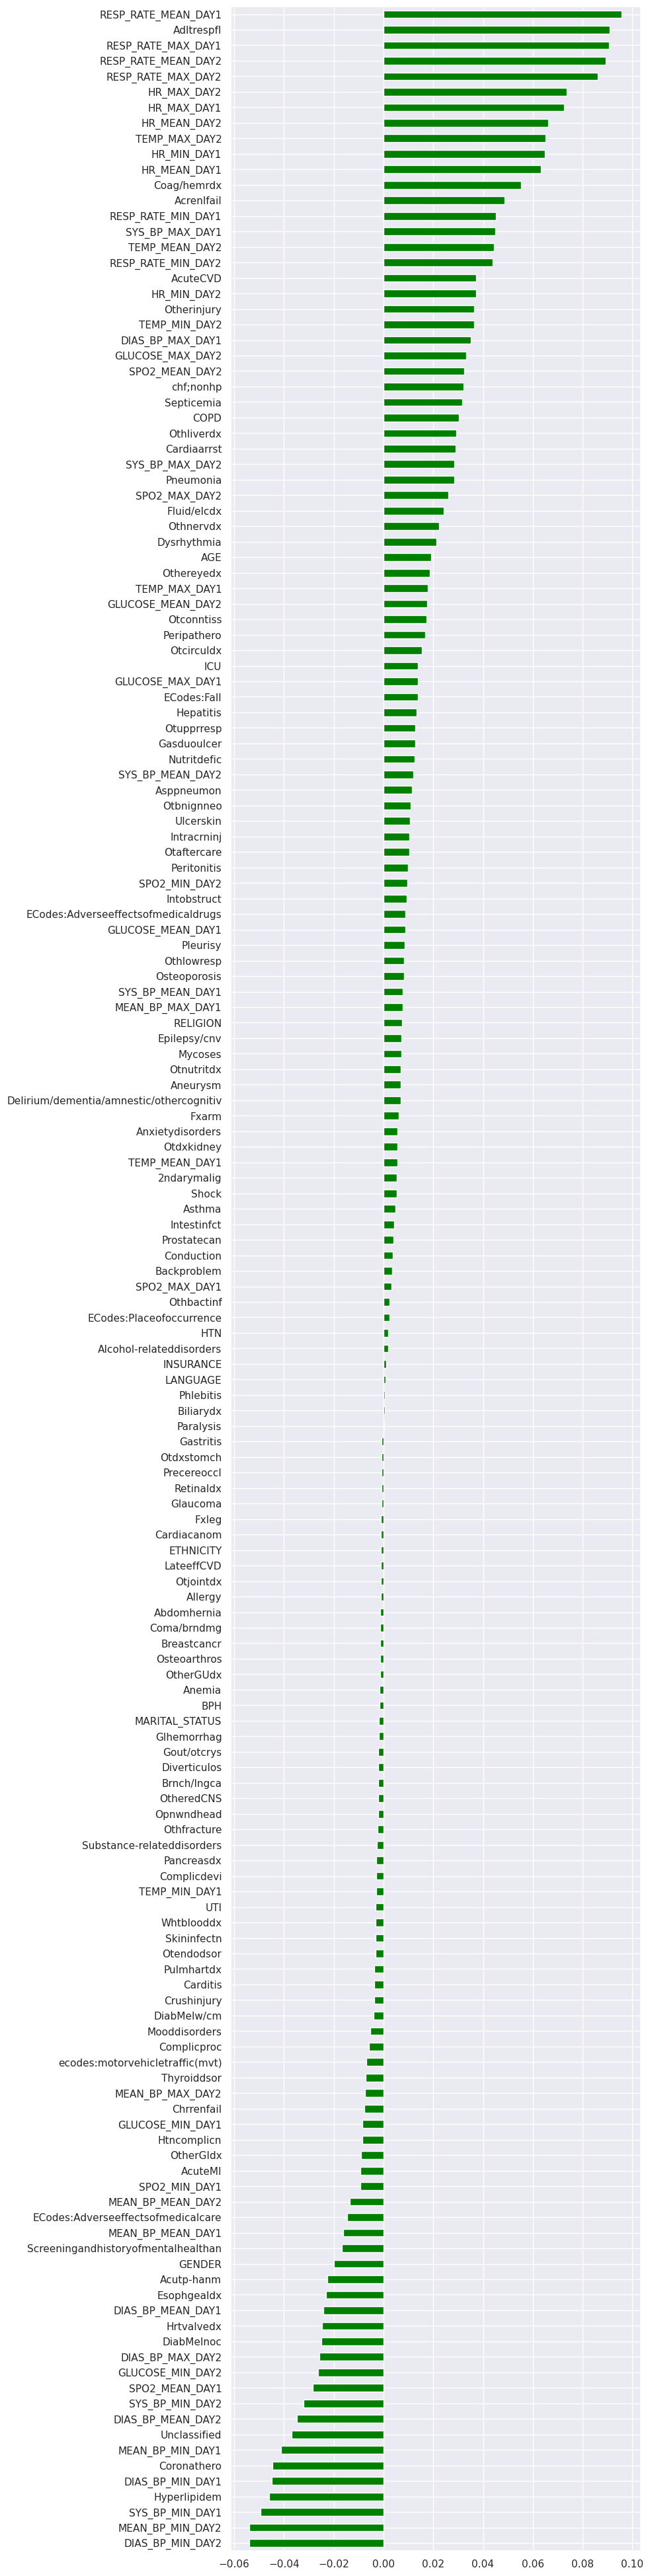

In [162]:
plt.figure(figsize=(8,50))
df_corr['Dead'].drop('Dead').dropna().sort_values().plot.barh(stacked=False, color='green')

Astuce :

* Utilisez un graphique avec des barres horizontales `barh` (pour visualiser les valeurs positives et négatives)

<ul style="color:#000099">
<li>    
 Choix pour la representation graphique :
    <p>
  Nous avons sélectionnée uniquement les correlations avec ys ici l'attribut dead pour les representer en barh . 
  Nous avons également négligé la correlation Dead et lui meme ainsi que les correlations qui n'ont pu être déterminé (avec des NAN).</p></li>
<li>  Par conséquent, d'après le graphique obtenu on peut considéré que les attibuts les plus corrélés sont : resp_rate_mean_day1 , Adltrespfl,resp_rate_max_day1
  donc la chance de mourir est plus probable si le patient a des problemes de respiration (Adltrespfl). 
    <p> De plus, il est potentiellement possible de prédire la mort du patient à partir de son état respiratoire lors de son arrivée à l'hôpital (day1)</p> </li>
<li>  D'autre part, on constate également qu'il y a des correllations négatives non négligeables avec les attibuts liée à la tension artérielle (BP : Blood Pressure ). On peut donc déduire que plus la tension artérielle est basse plus il est moins probable de survivre notamment lors du deuxième jour. </li>
</ul>

#### Autres graphiques ou résultats d'une analyse exploratoire

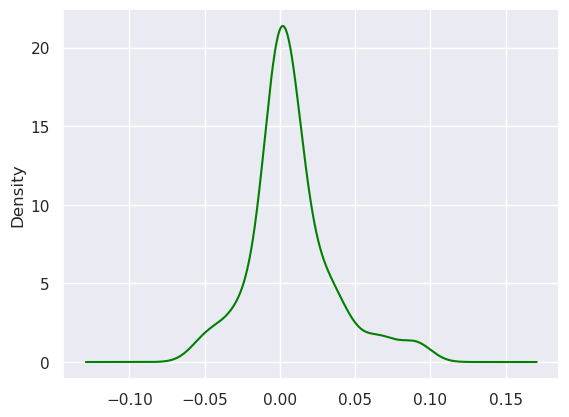

<Figure size 800x1000 with 0 Axes>

In [163]:
df_corr['Dead'].drop('Dead').dropna().plot(color='green',kind='density')
plt.figure(figsize=(8,10))
plt.show()

<ul style="color:#000099">
<li> D'après le graphique ci-dessus on constate explicitement que les correlations avec l'attribut Dead sont très proche de 0 (très faibles). </li>
<li> Par conséquent,les correlations les plus grandes par rapport à toutes les valeurs de correlations obtenues ne peuvent pas prédire de manière irréversible que le patient va mourir s'il est dans une situation qui correspond à une des correllations "haute" trouvées.</li>
</ul>

## 4. Pre-traitement

### Code : Traitement du problème des valeurs manquantes (ou non définies, NAN)

La solution la plus simple est d'éliminer l'ensemble des colonnes où il y a des données manquantes, mais on perd de l'information.

Vu le faible nombre d'instances concernées (maximum 6 : voir ci-dessous) il parait plus pertinent de supprimer les lignes (instances) plutôt que les colonnes entières (variables).

La solution que nous choisissons ici est une troisième, celle de remplacer les valeurs non définies par la valeur la plus probable de la variable. Comme ces valeurs manquantes concernent exclusivement des variables catégorielles et binaires, la valeur la plus probable est le *mode* (voir cours : `part-5-slides.pdf`).

In [164]:
print(x_df.shape, x_test_df.shape)

(79999, 337) (20001, 337)


In [165]:
x_nans = x_df.isna().sum()
x_miss = x_nans[x_nans > 0]
x_miss

LANGUAGE                              1
MARITAL_STATUS                        1
ICU                                   2
ECodes:Adverseeffectsofmedicalcare    6
Otnutritdx                            2
Othnervdx                             1
dtype: int64

In [166]:
x_test_nans = x_test_df.isna().sum()
x_test_miss = x_test_nans[x_test_nans > 0]
x_test_miss

LANGUAGE                              2
ECodes:Adverseeffectsofmedicalcare    3
dtype: int64

In [167]:
x_miss_rows = x_df.isna().any(axis="columns")

x_df.loc[x_miss_rows, x_miss.index]

,LANGUAGE,MARITAL_STATUS,ICU,ECodes:Adverseeffectsofmedicalcare,Otnutritdx,Othnervdx
2251,ENGL,MARRIED,MICU,NaN,0,0
9983,ENGL,MARRIED,MICU,0,NaN,0
10549,ENGL,MARRIED,MICU,0,NaN,0
10831,ENGL,MARRIED,MICU,NaN,1,0
17012,ENGL,MARRIED,CSRU,NaN,0,1
23088,ENGL,MARRIED,NaN,0,0,0
32539,ENGL,NaN,CSRU,0,0,0
42762,ENGL,SINGLE,TSICU,NaN,0,0
53191,NaN,MARRIED,MICU,0,0,0
53390,CAPE,MARRIED,NaN,0,0,0


#### Remplacement des NAN

In [168]:
na_cols = set(x_miss.index) | set(x_test_miss.index)

for col in na_cols:
    x_df[col].fillna(x_df[col].mode()[0], inplace=True)
    x_test_df[col].fillna(x_test_df[col].mode()[0], inplace=True)

In [169]:
print(
    x_df.isna().any().any(),
    x_test_df.isna().any().any(),
    sep="\n",
)

False
False


In [170]:
print(x_df.shape, x_test_df.shape)

(79999, 337) (20001, 337)


### Gestion des catégories rares

Simplifiez les données en regroupant par exemple les catégories rares.

In [171]:
def merge_rare_categories(dfs, col, keeps=None, keep_n=5):
    if keeps is None:
        keeps = x_df[col].value_counts()[:keep_n].index
        print(keeps)

    for df in dfs:
        df.loc[~df[col].isin(keeps), col] = "OTHER"


merge_rare_categories([x_df, x_test_df], col="RELIGION", keep_n=5)
print(x_test_df["RELIGION"].value_counts())

Index(['CATHOLIC', 'NOT_SPECIFIED', 'UNOBTAINABLE', 'PROTESTANT_QUAKER',
       'JEWISH'],
      dtype='object', name='RELIGION')
RELIGION
CATHOLIC             7517
NOT_SPECIFIED        3764
OTHER                2449
UNOBTAINABLE         2208
PROTESTANT_QUAKER    2208
JEWISH               1855
Name: count, dtype: int64


#### Code : Effectuez des regroupements de catégories rares pour d'autres variables si vous le jugez nécessaire

##### <b>Etape 1 :</b> prise en main des différentes catégories des attributs de type object

In [172]:
#extraction des attributs de type object
df_object = x_df.select_dtypes(include = 'object') 
df_object.head()

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,ICU
0,Private,ENGL,CATHOLIC,DIVORCED,WHITE,F,SICU
1,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,M,CCU
2,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,M,MICU
3,Medicare,ENGL,NOT_SPECIFIED,MARRIED,WHITE,M,CCU
4,Medicare,ENGL,UNOBTAINABLE,MARRIED,UNKNOWN/NOT_SPECIFIED,F,MICU


In [173]:
#compte le nombre de catégories pour chaque attribut de type object
df_object.nunique() 

INSURANCE          5
LANGUAGE          68
RELIGION           6
MARITAL_STATUS     7
ETHNICITY         41
GENDER             2
ICU                5
dtype: int64

##### <b>Etape 2 :</b> chercher la fréquence des catégories pour un attribut de type object  et en déduire les categories rares

###### <b>Calcul de la fréquence des catégories pour l'attribut LANGUAGE </b>

In [174]:
#calcul la frequence de chaque catégorie par rapport aux autre catégories (d'où la division par len(df_object))
lang_freq = df_object['LANGUAGE'].value_counts()/len(df_object)*100
lang_freq

LANGUAGE
ENGL      94.7
SPAN      1.09
RUSS     0.728
PTUN     0.693
CANT     0.383
         ...  
SERB     0.005
*LIT     0.005
*FAR   0.00375
*YID   0.00375
*PHI   0.00375
Name: count, Length: 68, dtype: float64

In [175]:
# TODO: Other application of merge_rare_categories
merge_rare_categories([x_df, x_test_df], col="LANGUAGE", keep_n=8)
print(x_test_df["LANGUAGE"].value_counts())

Index(['ENGL', 'SPAN', 'RUSS', 'PTUN', 'CANT', 'PORT', 'CAPE', 'HAIT'], dtype='object', name='LANGUAGE')
LANGUAGE
ENGL     18883
OTHER      332
SPAN       258
RUSS       151
PTUN       147
CANT        77
PORT        69
CAPE        43
HAIT        41
Name: count, dtype: int64


###### <b>Calcul de la fréquence des catégories pour l'attribut ETHNICITY </b>

In [176]:
#calcul la frequence de chaque catégorie par rapport aux autre catégories (d'où la division par len(df_object))
lang_freq = df_object['ETHNICITY'].value_counts()/len(df_object)*100
lang_freq

ETHNICITY
WHITE                                                         74.7
UNKNOWN/NOT_SPECIFIED                                         5.43
BLACK/AFRICAN_AMERICAN                                        4.65
OTHER                                                         2.06
HISPANIC_OR_LATINO                                            1.79
ASIAN                                                         1.77
UNABLE_TO_OBTAIN                                              1.73
PATIENT_DECLINED_TO_ANSWER                                    1.36
ASIAN_-_CHINESE                                              0.676
HISPANIC/LATINO_-_PUERTO_RICAN                               0.583
BLACK/CAPE_VERDEAN                                           0.533
WHITE_-_RUSSIAN                                              0.491
MULTI_RACE_ETHNICITY                                         0.446
HISPANIC/LATINO_-_DOMINICAN                                  0.363
BLACK/HAITIAN                                       

In [177]:
# TODO: Other application of merge_rare_categories
merge_rare_categories([x_df, x_test_df], col="ETHNICITY", keep_n=10)
print(x_test_df["ETHNICITY"].value_counts())

Index(['WHITE', 'UNKNOWN/NOT_SPECIFIED', 'BLACK/AFRICAN_AMERICAN', 'OTHER',
       'HISPANIC_OR_LATINO', 'ASIAN', 'UNABLE_TO_OBTAIN',
       'PATIENT_DECLINED_TO_ANSWER', 'ASIAN_-_CHINESE',
       'HISPANIC/LATINO_-_PUERTO_RICAN'],
      dtype='object', name='ETHNICITY')
ETHNICITY
WHITE                             14930
OTHER                              1423
UNKNOWN/NOT_SPECIFIED              1088
BLACK/AFRICAN_AMERICAN              930
UNABLE_TO_OBTAIN                    380
HISPANIC_OR_LATINO                  377
ASIAN                               354
PATIENT_DECLINED_TO_ANSWER          264
ASIAN_-_CHINESE                     144
HISPANIC/LATINO_-_PUERTO_RICAN      111
Name: count, dtype: int64


 <p style="color:#000099">
 D'après les résultats obtenue par rapport à la proportion des catégories pour l'attribut LANGUAGE et ETHNICITY , on peut déduire que ces attributs contiennent plusieurs catégories rares (fréquence faible) d'où l'utilité de regrouper ces catégories en une seule noté OTHER (cela va simplifier les données fournies)</p>

### Transformation des données catégorielles en nombres entiers en utilisant deux types d'encodage

Les variables catégorielles sont présentées sous forme de chaines de caractères. La plupart des modèles ne pourront pas les prendre en entrée.

#### Encodage numérique simple

Deux des méthodes les plus simples sont `LabelEncoder` de Scikit-Learn et `factorize` de pandas. Elles consistent simplement à remplacer chaque nouvelle catégorie rencontrée par un entier, en commençant par 0. Ce n'est cependant peut-être pas la méthode la plus efficace, car elle présuppose une proximité entre les catégories codées avec des valeurs proches.

In [178]:
def label_encode(df, other_df, only_binary=False):
    """
    Select categorical variables and encode them in integers.
    """
    char_cols = df.dtypes.pipe(lambda x: x[x == "object"]).index
    # print(char_cols)

    for col in char_cols:
        n_categories = len(x_df[col].unique())

        if not only_binary or n_categories == 2:
            codes, uniques = pd.factorize(df[col])
            df[col] = codes

            # Create conversion dic to convert values of test set as well
            cat2code = {k: v for v, k in enumerate(uniques)}
            other_df[col] = other_df[col].map(cat2code)

In [179]:
x_df.head(3)

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,Private,ENGL,CATHOLIC,DIVORCED,WHITE,F,21,57.2,109,70.8,...,0,0,0,0,0,0,0,0,0,0
1,Private,ENGL,UNOBTAINABLE,SINGLE,WHITE,M,39,79.3,121,96.9,...,0,0,0,0,0,0,0,0,0,1
2,Medicaid,SPAN,CATHOLIC,WIDOWED,OTHER,M,40,118,175,141,...,0,0,0,0,0,0,0,0,0,0


In [180]:
print(x_df.shape, ys.shape)

(79999, 337) (79999,)


In [181]:
x_fact_df = x_df.copy()
x_test_fact_df = x_test_df.copy()

label_encode(x_fact_df, x_test_fact_df)

In [182]:
x_fact_df.head(3)

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,0,0,0,0,0,0,21,57.2,109,70.8,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,1,39,79.3,121,96.9,...,0,0,0,0,0,0,0,0,0,1
2,1,1,0,2,1,1,40,118,175,141,...,0,0,0,0,0,0,0,0,0,0


In [183]:
x_test_fact_df.head(3)

,INSURANCE,LANGUAGE,RELIGION,MARITAL_STATUS,ETHNICITY,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,...,Eyeinfectn,Othereyedx,Otitismedia,Dizziness,Othereardx,Othnervdx,Hrtvalvedx,Carditis,HTN,Htncomplicn
0,3,0,5,3,0,0,18,72.6,113,96.5,...,0,0,0,0,0,0,0,0,0,0
1,2,0,2,1,3,0,56,66.6,107,83.8,...,0,0,0,0,0,0,0,0,1,0
2,1,0,0,1,0,1,32,69.7,103,87.3,...,0,0,0,0,0,0,0,0,0,0


#### Encodage 1-Hot

Un autre type d'encodage est souvent plus efficace, il a notamment l'avantage de ne pas ordonner les classes d'une manière particulière (pas forcément en adéquation avec la proximité de ces classes entre elles).

Une méthode de pandas permet de le réaliser en 1 ligne de code avec la fonction `get_dummies`.

Exemple d'encodage 1-hot avec la fonction `get_dummies` de pandas (pour MARITAL_STATUS) :

|    |   DIVORCED |   LIFE_PARTNER |   MARRIED |   SEPARATED |   SINGLE |   UNKNOWN_(DEFAULT) |   WIDOWED |
|---:|-----------:|---------------:|----------:|------------:|---------:|--------------------:|----------:|
|  0 |          1 |              0 |         0 |           0 |        0 |                   0 |         0 |
|  1 |          0 |              0 |         0 |           0 |        1 |                   0 |         0 |
|  2 |          0 |              0 |         0 |           0 |        0 |                   0 |         1 |
|  3 |          0 |              0 |         1 |           0 |        0 |                   0 |         0 |
|  4 |          0 |              0 |         1 |           0 |        0 |                   0 |         0 |

In [184]:
# Encode binary features on a single column (no need for 1-hot)
label_encode(x_df, x_test_df, only_binary=True)

x_all_1h_df = pd.get_dummies(pd.concat([x_df, x_test_df]))

x_1h_df = x_all_1h_df.iloc[: len(x_df)].copy()
x_test_1h_df = x_all_1h_df.iloc[len(x_df):].copy()

print(x_df.shape, x_test_df.shape)
print(x_1h_df.shape, x_test_1h_df.shape)

(79999, 337) (20001, 337)
(79999, 373) (20001, 373)


#### Suppression des variables à valeur unique (constantes)

In [185]:
const_cols = {col for col in x_1h_df if len(x_1h_df[col].unique()) == 1}
len(const_cols)

173

In [186]:
x_1h_df.drop(const_cols, axis="columns", inplace=True)
x_test_1h_df.drop(const_cols, axis="columns", inplace=True)

print(x_1h_df.shape, x_test_1h_df.shape)

(79999, 200) (20001, 200)


### Création de l'ensemble de validation

In [187]:
x_train, x_valid, y_train, y_valid = model_selection.train_test_split(
    x_1h_df, ys, test_size=0.3
)
# VARS: x_df, x_fact_df, x_1h_df

In [188]:
x_1h_df

,GENDER,AGE,HR_MIN_DAY1,HR_MAX_DAY1,HR_MEAN_DAY1,SYS_BP_MIN_DAY1,SYS_BP_MAX_DAY1,SYS_BP_MEAN_DAY1,DIAS_BP_MIN_DAY1,DIAS_BP_MAX_DAY1,...,ETHNICITY_OTHER,ETHNICITY_PATIENT_DECLINED_TO_ANSWER,ETHNICITY_UNABLE_TO_OBTAIN,ETHNICITY_UNKNOWN/NOT_SPECIFIED,ETHNICITY_WHITE,ICU_CCU,ICU_CSRU,ICU_MICU,ICU_SICU,ICU_TSICU
0,0,21,57.2,109,70.8,79.8,120,94.4,26.9,68.9,...,False,False,False,False,True,False,False,False,True,False
1,1,39,79.3,121,96.9,94,139,114,38.6,74.3,...,False,False,False,False,True,True,False,False,False,False
2,1,40,118,175,141,123,144,135,67.8,83.3,...,True,False,False,False,False,False,False,True,False,False
3,1,75,83.8,89.2,86.1,111,145,128,61.1,75.2,...,False,False,False,False,True,True,False,False,False,False
4,0,55,60.9,106,80.6,87.6,128,99.1,42.7,64,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79994,0,76,56,97.9,79.7,77.5,120,102,26.7,49.7,...,False,False,False,False,True,False,True,False,False,False
79995,0,38,55.1,86,67.6,83.1,175,119,40.4,79.4,...,False,False,False,False,True,False,False,False,False,True
79996,0,90,74.3,91.3,91.4,95.9,139,131,52.7,85.1,...,False,False,False,False,True,False,False,False,True,False
79997,1,57,79.3,129,98.7,108,142,132,57.1,77.4,...,False,False,False,False,False,False,False,False,False,True


### Réduction de la dimension via l'ACP (PCA)

Testez l'ACP pour réduire le nombre de dimensions et observez si cela améliore le résultat.

Avant d'appliquer la ACP, il est conseillé de centrer-réduire les données (e.g., via `preprocessing.StandardScaler()`).

In [189]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_1h_df)

N_COMP = 2
pca = PCA(n_components=N_COMP)
X_pca = pca.fit_transform(X_scaled)

X_pca_train, X_pca_test, yp_train, yp_test = train_test_split(X_pca, ys, test_size=0.2, random_state=42)

Proposez un graphique qui représente les 2 premières dimensions de la PCA et commentez succinctement.

In [190]:
#CREDIT CORRECTIONS PRECEDENTES 
def plot_points(xs, ys, ft_names=(None, None), target_names=None, colors=None):
    if target_names is None:
        target_names = {}
    if colors is None:
        colors = {}

    for y_val in set(ys):
        plt.scatter(
            xs[ys == y_val, 0],
            xs[ys == y_val, 1],
            color=colors.get(y_val),
            alpha=0.8,
            label=target_names.get(y_val),
            edgecolor="gray",
        )
    plt.legend(loc="best", shadow=False, scatterpoints=1)
    plt.title("")
    try:
        plt.xlabel(ft_names[0])
        plt.ylabel(ft_names[1])
    except TypeError:
        pass

 <p style="color:#000099"> On affiche les 2 premières dimensions du PCA à travers un plot point </p>

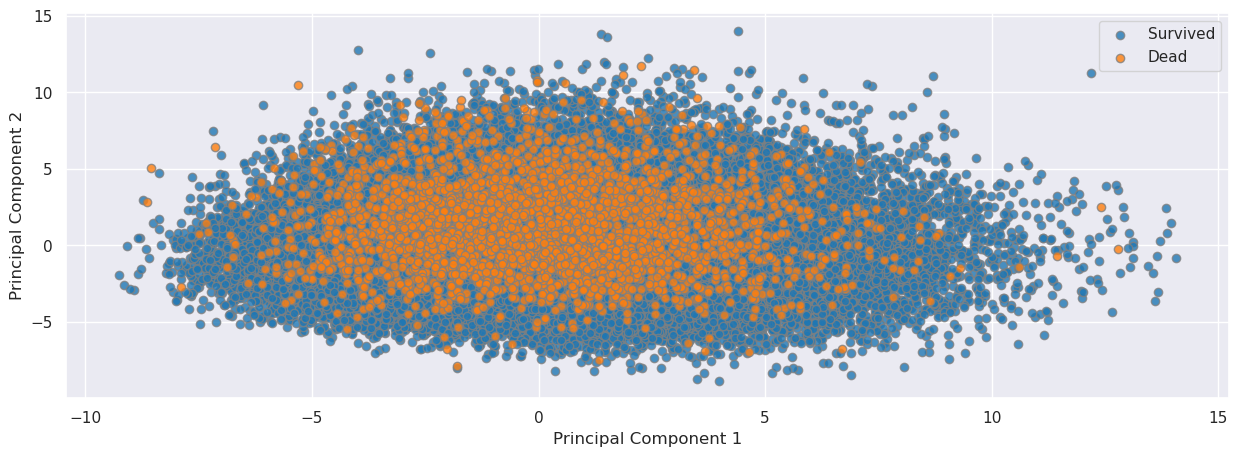

In [191]:
plt.figure(figsize=(15,5))
target_names={0: "Survived", 1:"Dead"}
plot_points(X_pca, ys,("Principal Component 1", "Principal Component 2"), target_names)

<ul style="color:#000099">
    
<li> Les résultats obtenus avec le PCA ne permettent pas d'aboutir à une interpretation interressante des prédictions, d'après cette représentation on ne peut seulement constaté que les survivants représentent une proportion plus grande par rapport aux non survivants chose qu'on a  déja constaté auparavant avec la représentation graphique des valeurs de la colonne "Dead". </li>
<li> D'autre part, on sait que le PCA est un algorithme d'apprentissage non supervisé mais ici on est dans une situation d'apprentissage supervisé cela peut expliqué le fait que les résultats obtenu ne sont pas significatif  dans notre situation. PCA réduit la dimension des la base données qu'on a, il donc utile pour réaliser des apprentissage automatique plus rapide sur différents modèles </li>
</ul>

## 5. Modèles de classification

Entrainez le modèle

### Baseline

`LogisticRegression` or `RandomForestClassifier`

In [192]:
SCORINGS = "balanced_accuracy"

 <p style="color:#000099"> Nous entrainons les modèles sur le dataset complet et en plus de cela sur les dataset obtenu via l'ACP, puis nous comparons les résultats. </p>

In [193]:
model_rf = ensemble.RandomForestClassifier(n_estimators=10)
model_rf.fit(x_train, y_train)  # training

modelp_rf = ensemble.RandomForestClassifier(n_estimators=10)
modelp_rf.fit(X_pca_train, yp_train) 

RandomForestClassifier(n_estimators=10)

In [194]:
model_svc = svm.LinearSVC(dual=False)
model_svc.fit(x_train, y_train)

modelp_svc = svm.LinearSVC(dual=False)
modelp_svc.fit(X_pca_train, yp_train)

LinearSVC(dual=False)

In [195]:
model_NB = naive_bayes.GaussianNB()
model_NB.fit(x_train, y_train) 

modelp_NB = naive_bayes.GaussianNB()
modelp_NB.fit(X_pca_train, yp_train) 

GaussianNB()

In [196]:
model_DTR = tree.DecisionTreeRegressor(random_state=42)
model_DTR.fit(x_train, y_train) 

modelp_DTR = tree.DecisionTreeRegressor(random_state=42)
modelp_DTR.fit(X_pca_train, yp_train) 

DecisionTreeRegressor(random_state=42)

In [197]:
model_DT = tree.DecisionTreeClassifier(random_state=42)
model_DT.fit(x_train, y_train) 

modelp_DT = tree.DecisionTreeClassifier(random_state=42)
modelp_DT.fit(X_pca_train, yp_train) 

DecisionTreeClassifier(random_state=42)

## 6. Évaluations

In [198]:
y_pred_DTR = model_DTR.predict(x_valid)  # predictions
y_pred_pca_DTR= modelp_DTR.predict(X_pca_test)

score = metrics.balanced_accuracy_score(y_valid, y_pred_DTR)  # scoring
scorep = metrics.balanced_accuracy_score(yp_test, y_pred_pca_DTR) 

In [199]:
print(f"Decision Tree Regressor results :") 
print(f"Balanced accuracy score: {score:.3g}")
print(f"Balanced accuracy score PCA: {scorep:.3g}")

Decision Tree Regressor results :
Balanced accuracy score: 0.533
Balanced accuracy score PCA: 0.502


In [200]:
y_pred_svc = model_svc.predict(x_valid)  # predictions
y_pred_pca_svc = modelp_svc.predict(X_pca_test)

score = metrics.balanced_accuracy_score(y_valid, y_pred_svc)  # scoring
scorep = metrics.balanced_accuracy_score(yp_test, y_pred_pca_svc) 


In [201]:
print(f"SVC results :") 
print(f"Balanced accuracy score: {score:.3g}")
print(f"Balanced accuracy score PCA: {scorep:.3g}")

SVC results :
Balanced accuracy score: 0.5
Balanced accuracy score PCA: 0.5


In [202]:
y_pred_nb = model_NB.predict(x_valid)  # predictions
y_pred_pca_nb = modelp_NB.predict(X_pca_test)  


score = metrics.balanced_accuracy_score(y_valid, y_pred_nb)  # scoring
scorep = metrics.balanced_accuracy_score(yp_test, y_pred_pca_nb) 


In [203]:
print(f"Gaussian NB results :") 
print(f"Balanced accuracy score: {score:.3g}")
print(f"Balanced accuracy score PCA: {scorep:.3g}")

Gaussian NB results :
Balanced accuracy score: 0.511
Balanced accuracy score PCA: 0.501


In [204]:
y_pred_rf = model_rf.predict(x_valid)  # predictions
y_pred_pca_rf = modelp_rf.predict(X_pca_test)  

score = metrics.balanced_accuracy_score(y_valid, y_pred_rf)  # scoring
scorep = metrics.balanced_accuracy_score(yp_test, y_pred_pca_rf) 

In [205]:
print(f"Random Forest results :") 
print(f"Balanced accuracy score: {score:.3g}")
print(f"Balanced accuracy score PCA: {scorep:.3g}")

Random Forest results :
Balanced accuracy score: 0.5
Balanced accuracy score PCA: 0.5


In [206]:
y_pred_dt = model_DT.predict(x_valid)  # predictions
y_pred_pca_dt = modelp_DT.predict(X_pca_test)  

score = metrics.balanced_accuracy_score(y_valid, y_pred_dt)  # scoring
scorep = metrics.balanced_accuracy_score(yp_test, y_pred_pca_dt) 

In [207]:
print(f"Decision Tree Classifier results :") 
print(f"Balanced accuracy score: {score:.3g}")
print(f"Balanced accuracy score PCA: {scorep:.3g}")

Decision Tree Classifier results :
Balanced accuracy score: 0.533
Balanced accuracy score PCA: 0.502


### Code : Validation croisée

Le code ci-dessus utilise une méthode simple (*hold out*) pour mesurer le score de validation. Utilisez la validation croisée (pour obtenir une estimation plus fiable) combinée à l'exploration des hyperparamètres (pour améliorer les résultats).

Vous pouvez changer la valeur du nombre de validation croisée (CV) selon la valeur de l'erreur et le temps d'entrainement des modèles (compromis).

In [208]:
CV = 10

In [209]:
rf_val_score = model_selection.cross_val_score(model_rf, X_pca_train, yp_train, cv=CV, scoring=SCORINGS)
print(f"RandomForest : {rf_val_score.mean():g}")

RandomForest : 0.500734


In [210]:
nb_val_score = model_selection.cross_val_score(model_NB, X_pca_train, yp_train, cv=CV, scoring=SCORINGS)
print(f"GaussianNB : {nb_val_score.mean():g}")

GaussianNB : 0.50006


In [211]:
svc_val_score = model_selection.cross_val_score(model_svc, X_pca_train, yp_train, cv=CV, scoring=SCORINGS)
print(f"LinearSVC : {svc_val_score.mean():g}")

LinearSVC : 0.5


In [212]:
dtr_val_score = model_selection.cross_val_score(model_DTR, X_pca_train, yp_train, cv=CV, scoring=SCORINGS)
print(f"DecisionTreeRegressor : {dtr_val_score.mean():g}")

DecisionTreeRegressor : 0.501014


In [213]:
dt_val_score = model_selection.cross_val_score(model_DT, X_pca_train, yp_train, cv=CV, scoring=SCORINGS)
print(f"DecisionTreeClassifier : {dt_val_score.mean():g}")

DecisionTreeClassifier : 0.50193


* **Pour 2 des modèles** (au moins 1 autre que les 2 proposés en baselines) :

    * Pour différentes valeurs d'un des hyperparamètres, donnez les `balanced_accuracy` moyennes de la validation croisée sous forme de Boxplots (ou de diagramme à bâtons avec une barre d'erreur) : voir l'exemple présenté dans le graphique ci-dessous.
    
    * Explicitez succinctement quelles observations en tirer concernant la stabilité des prédictions.

![](img/boxplot-cv.png)

 <span style="color:#000099"> ***Random forest Classifier Hyperparameter Tuning withouth gridSearch*** </span>

In [214]:
hyper_parametres = [4, 6, 9, 10, 15]

balanced_accuracy_scores = []

for value in hyper_parametres:
    rfc = ensemble.RandomForestClassifier(n_estimators=value) 
    rfc.fit(X_pca_train, yp_train)  

    y_pred = rfc.predict(X_pca_test) 
    
    score= model_selection.cross_val_score(rfc, X_pca_train, yp_train, cv=CV, scoring=SCORINGS)
    #score = metrics.balanced_accuracy_score(y_valid, y_pred)

    balanced_accuracy_scores.append(score)

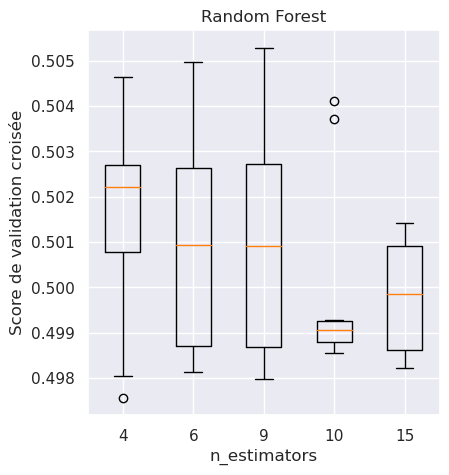

In [215]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,2)
#sns.boxplot(x='n_estimators', y='balanced_accuracy', data=res)
plt.boxplot(balanced_accuracy_scores, 
            labels=hyper_parametres)
plt.title('Random Forest')
plt.xlabel('n_estimators')
plt.ylabel('Score de validation croisée')
plt.grid(True)
plt.show()

<b>Interpretation</b>
<ul style="color:#000099">
<pa>(notez bien que les valeurs de l'accuracy peuvent varier d'une execution à une autre, car les split de données ne sont pas toujours les mêmes)</pa>
<li> D'après le graphique ci dessus la meilleure valeur de l'hyperparametre n_estimators est de 6 . En effet, on remarque que 50 % des prédictions ont un score de validation compris entre 0.5 et 0.505. </li>
<li> On remarque également que la boxe est plus grande pour la valeur de n_estimators = 6  par rapport aux autre valeur. Cela signifie que les valeur sont plus hétérogènes. </li>
</ul>

 <span style="color:#000099"> ***Random forest Classifier Hyperparameter Tuning with gridSearch*** </span>

In [216]:
from sklearn.model_selection import GridSearchCV

rf = ensemble.RandomForestClassifier()

parameters = {'n_estimators': [4, 6, 9, 10, 15] }

search = GridSearchCV(rf, parameters)
search = search.fit(X_pca_train, yp_train)

In [217]:
print("Best Model Parameters:", search.best_params_)

cv_results_df = pd.DataFrame(search.cv_results_)

with pd.option_context("display.float_format", "{:.2g}".format):
    display(cv_results_df)

Best Model Parameters: {'n_estimators': 10}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.46,0.023,0.013,0.00057,4,{'n_estimators': 4},0.96,0.96,0.96,0.96,0.96,0.96,0.00055,5
1,0.68,0.034,0.017,0.00072,6,{'n_estimators': 6},0.96,0.96,0.96,0.96,0.96,0.96,0.00029,3
2,0.94,0.026,0.024,0.00083,9,{'n_estimators': 9},0.96,0.96,0.96,0.96,0.96,0.96,0.00062,4
3,1.2,0.031,0.029,0.00052,10,{'n_estimators': 10},0.96,0.96,0.96,0.96,0.96,0.96,0.00026,1
4,1.7,0.061,0.041,0.0016,15,{'n_estimators': 15},0.96,0.96,0.96,0.96,0.96,0.96,0.00049,2


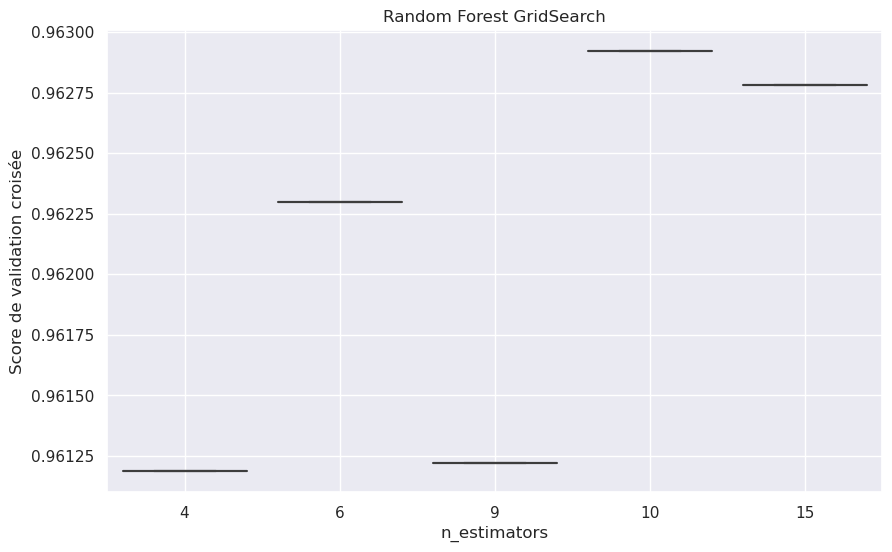

In [218]:
import seaborn as sns

param = search.cv_results_["param_n_estimators"]
scores = search.cv_results_["mean_test_score"]
res= pd.DataFrame({
    'n_estimators' :param,
    'balanced_accuracy': scores
})
    
plt.figure(figsize=(10, 6))
sns.boxplot(x='n_estimators', y='balanced_accuracy', data=res)
plt.title('Random Forest GridSearch')
plt.xlabel('n_estimators')
plt.ylabel('Score de validation croisée')
plt.grid(True)
plt.show()


<b>Interpretation</b>
<ul style="color:#000099">
<li> D'après le graphique ci dessus la meilleure valeur de l'hyperparametre n_estimators est de 10 . En effet, on remarque que la précision du modèle est d'environ 0.96300. </li>
</ul>

 <span style="color:#000099"> ***Decision Tree Classifier Hyperparameter Tuning withouth gridSearch*** </span>

In [219]:
hyper_parametres =[2, 3, 6, 10, 20]

balanced_accuracy_scores_dt = []

for value in hyper_parametres:
    dt = tree.DecisionTreeClassifier(random_state=42,max_depth=value)
    dt.fit(X_pca_train, yp_train)  

    y_pred_dt = dt.predict(X_pca_test) 
    
    score= model_selection.cross_val_score(dt, X_pca_train, yp_train, 
                                           cv=CV, scoring=SCORINGS)
    #score = metrics.balanced_accuracy_score(y_valid, y_pred_dt)

    balanced_accuracy_scores_dt.append(score)

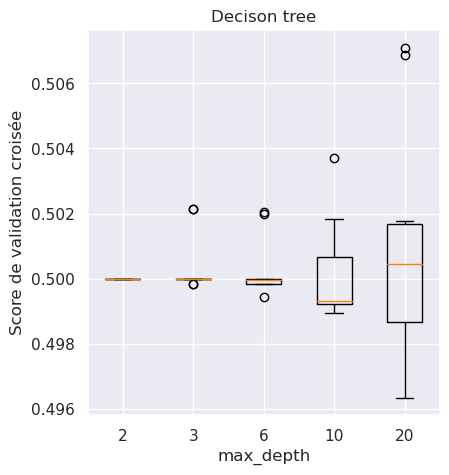

In [220]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,2)
#sns.boxplot(x='n_estimators', y='balanced_accuracy', data=res)
plt.boxplot(balanced_accuracy_scores_dt, 
            labels=hyper_parametres)
plt.title('Decison tree')
plt.xlabel('max_depth')
plt.ylabel('Score de validation croisée')
plt.grid(True)
plt.show()

<b>Interpretation</b>
<ul style="color:#000099">
<pa>(notez bien que les valeurs de l'accuracy peuvent varier d'une execution à une autre, car les split de données ne sont pas toujours les mêmes)</pa>
<li> D'après le graphique ci dessus la meilleure valeur de l'hyperparametre max_depth est de 20 . En effet, on remarque que 50 % des prédictions ont un score de validation compris entre 0.499 et 0.506. En même temps, on remarque que plus 50% des predictions sont très bases a comparaison des autres, arrivant aussi bas que 0.494. </li> 
<li> On remarque également que la boxe est plus grande pour la valeur de max_depth = 20  par rapport aux autres valeurs. Cela signifie que les valeurs sont plus hétérogènes. </li>
<ul>

 <span style="color:#000099"> ***Random forest Classifier Hyperparameter Tuning with gridSearch*** </span>

In [221]:
from sklearn.model_selection import GridSearchCV

dt = tree.DecisionTreeClassifier(random_state=42)

parameters = {'max_depth': [2, 3, 6, 10, 20] }

search = GridSearchCV(dt, parameters)
search = search.fit(X_pca_train, yp_train)

In [222]:
print("Best Model Parameters:", search.best_params_)

cv_results_dt = pd.DataFrame(search.cv_results_)

with pd.option_context("display.float_format", "{:.2g}".format):
    display(cv_results_dt)

Best Model Parameters: {'max_depth': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.039,0.001,0.0016,0.00018,2,{'max_depth': 2},0.96,0.96,0.96,0.96,0.96,0.96,3e-05,1
1,0.055,0.0013,0.0017,8.6e-05,3,{'max_depth': 3},0.96,0.96,0.96,0.96,0.96,0.96,9.3e-05,2
2,0.1,0.0025,0.0024,0.00027,6,{'max_depth': 6},0.96,0.96,0.96,0.96,0.96,0.96,0.00013,3
3,0.16,0.0038,0.0025,0.00014,10,{'max_depth': 10},0.96,0.96,0.96,0.96,0.96,0.96,0.00041,4
4,0.27,0.0058,0.0036,0.00011,20,{'max_depth': 20},0.95,0.95,0.95,0.95,0.95,0.95,0.0012,5


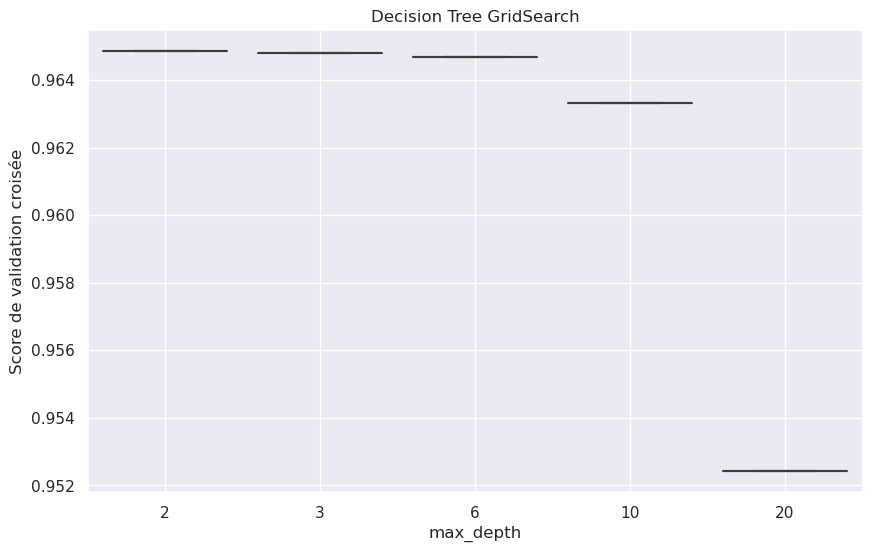

In [223]:
param = search.cv_results_["param_max_depth"]
scores = search.cv_results_["mean_test_score"]
res= pd.DataFrame({
    'max_depth' :param,
    'balanced_accuracy': scores
})
    
plt.figure(figsize=(10, 6))
sns.boxplot(x='max_depth', y='balanced_accuracy', data=res)
plt.title('Decision Tree GridSearch')
plt.xlabel('max_depth')
plt.ylabel('Score de validation croisée')
plt.grid(True)
plt.show()

<b>Interpretation</b>
<ul style="color:#000099">
<li> D'après le graphique ci dessus les meilleures valeurs de l'hyperparametre n_estimators est de  2 et 3 . En effet, on remarque que la précision du modèle est d'environ 0.9650. </li>
<ul>

* **Pour chacun de ces 2 modèles, à partir des données de validation créées précédemment** (`x_valid`, `y_valid`) :

    * Mesurez l'aire sous la courbe ROC (AUC) à l'aide de la fonction de Scikit-Learn (`roc_auc_score`) et comparez les modèles avec leur combinaison respective d'hyperparamètres offrant le meilleur résultat.

 <span> ***TODO: ROC*** </span>

In [224]:
rf1 = ensemble.RandomForestClassifier(n_estimators=6).fit(x_valid, y_valid)
print(f"Sans GridSearch: {metrics.roc_auc_score(y_valid, rf1.predict(x_valid)):g}")

rf15 = ensemble.RandomForestClassifier(n_estimators=15).fit(x_valid, y_valid)
print(f"Avec GridSearch: {metrics.roc_auc_score(y_valid, rf15.predict(x_valid)):g}")

Sans GridSearch: 0.836775
Avec GridSearch: 0.952323


<b>Interprétation</b> : 
<ul style="color:#000099">
<li> Grace à la recherche du meilleur hyperparamètre avec GridSearch nous avons une aire sous la courbe très proche de 1 ce qui montre que la meilleure valeur pour n_estimators est de 15</li>
</ul>

In [225]:
dt20 = tree.DecisionTreeClassifier(random_state=42, max_depth=20).fit(x_valid, y_valid)
print(f"Sans GridSearch: {metrics.roc_auc_score(y_valid, dt20.predict(x_valid)):g}")

dt6 = tree.DecisionTreeClassifier(random_state=42, max_depth=6).fit(x_valid, y_valid)
print(f"Avec GridSearch: {metrics.roc_auc_score(y_valid, dt6.predict(x_valid)):g}")

Sans GridSearch: 0.808047
Avec GridSearch: 0.542658


<b>Interprétation</b> : 
<ul style="color:#000099">
<li> Grace à la recherche du meilleur hyperparamètre sans GridSearch  nous avons une aire sous la courbe très proche de 1 ce qui montre que la meilleure valeur pour max_depth est de 20. </li>
</ul>

* **Pour le modèle et sa combinaison d'hyperparamètres offrant le meilleur résultat** :

    * Réalisez la matrice de confusion et décrivez-la succinctement.

***TODO: Confusion Matrix***

In [226]:
print("Matrice de confusion pour RandomForest : ")
print("Parametre sans GridSearch")
print(metrics.confusion_matrix(y_valid, rf1.predict(x_valid)))

print("Parametre avec GridSearch")
print(metrics.confusion_matrix(y_valid, rf15.predict(x_valid)))

Matrice de confusion pour RandomForest : 
Parametre sans GridSearch
[[23181     1]
 [  267   551]]
Parametre avec GridSearch
[[23182     0]
 [   78   740]]


<b>Interprétation</b> : 
<ul style="color:#000099">    
    <li> Cas 1 : Sans GridSearch </li>
    <p> On a 336 faux positifs et 296 faux négatifs ce qui aboutit à une confusion non négligeable</p>
    <li> Cas 2 : Avec GridSearch </li>
<p>On a 0 faux positifs et 87 faux négatifs ce qui aboutit à une confusion moins significative par rapport au cas 1</p>
</ul>

In [227]:
print("Matrice de confusion pour DesicionTree : ")
print("Parametre sans GridSearch")
print(metrics.confusion_matrix(y_valid, dt20.predict(x_valid)))

print("Parametre avec GridSearch")
print(metrics.confusion_matrix(y_valid, dt6.predict(x_valid)))

Matrice de confusion pour DesicionTree : 
Parametre sans GridSearch
[[23181     1]
 [  314   504]]
Parametre avec GridSearch
[[23176     6]
 [  748    70]]


<b>Interprétation</b> : 
<ul style="color:#000099">
    <li> Cas 1 : Sans GridSearch </li>
<p> On a 1 faux positif et 205 faux négatifs ce qui aboutit à une confusion moins significative par rapport au cas 2</p>
    <li> Cas 2 : Avec GridSearch </li>
<p> On a 0 faux positifs mais 819 faux négatifs ce qui aboutit à une confusion non négligeable d'où une précision plus faible par rapport au cas 1 </p>
</ul>

### Code : Essayez d'améliorer votre score

* Data augmentation (optionnel)

Vu le déséquilibre entre les classes à prédire (survive, died), on peut espérer améliorer le score en les rééquilibrant. Une approche typique est la génération de données (voir cours : `part-6-slides.pdf`). Une des méthodes de génération est [SMOTE](https://en.wikipedia.org/wiki/Oversampling_and_undersampling_in_data_analysis#SMOTE) (voir cours théorique), elle est notamment implémentée dans le module `imblearn`.

`imblearn` a été développé pour s'interfacer facilement avec `sklearn`.
Il propose notamment une version du `pipeline` qui permet l'intégration avec `sklearn`.

Ci-dessous voici un exemple de `pipeline` intégrant `imblearn` et `sklearn`.

***TODO: Data augmentation***



In [228]:
pipe = imblearn.pipeline.Pipeline(
    [
        ("scale", preprocessing.StandardScaler()),
        ("pca", decomposition.PCA()),
        ("resample", imblearn.over_sampling.SMOTE()),
        ("model", dt6),
    ]
)

pipe.fit(x_train, y_train)
pipe_pred = pipe.predict(x_valid)
score_pipe = metrics.balanced_accuracy_score(y_valid, pipe_pred)
score_pipe

0.614641840193439

### Explication de ce que vous avez réalisé, conclusion et perspectives

* Commencez par donner votre meilleur résultat obtenu lors de vos soumissions

* Expliquez le chemin qui vous y a conduit

    * Ce que vous avez essayé :

        * Ce qui a fonctionné

        * Ce qui n'a pas fonctionné et comment vous l'avez solutionné

    * Quelle méthode avez-vous utilisée pour choisir les hyperparamètres ?

    * Comparer la durée d'entrainement des principaux modèles utilisés ?

* Qu'auriez-vous fait si vous aviez eu plus de temps ?

#### ***SYNTHESE***

##### Notre meilleur résultat
- A partir du confusion matrix et ROC AUC, on peut dire que notre meilleure resultat vient du modele RandomForest avec le parametre n_composant = 15 . 
- Cependant en réalisant le pipeline sur  Decision tree avec comme hyperparamètre max_depth = 6 on obtient de meilleures performances . Notons que la valeur 6 pour max_depth était une des meilleur valeur choisie (cf box plot) .  - La phase pipeline améliore donc la performance du modèle decision tree qui n'était considéré comme le plus précis.

##### Ce qu'on a réalisé
- Nous avons cherché les correlations possibles avec l'attribut dead et les autres attributs pour avoir une idées des possibles relation entre les données. Notons que pour cette étapes nous avons fait le choix d'encoder les attibuts  de type catégories en des valeurs numériques pour pouvoir les intégrer dans la correlation.

- Nous avons également réduit les attibuts LANGUAGE et ETHNICITY pour avoir une base de donnée plus simple notamment pour les attributs de type object

- Pour choisir le meilleur modèle de prédictions , nous avons choisi de comparer différents classificateurs notamment RandomForest DecisionTree et LinearSVC . Pour chaque modèle nous avons fait varier les valeur de certains hyperparamètres pour comparer la performance de chaque modèle avec différentes valeur d'hyperparmètre.

- Le choix des hyperparamètre à été réalisé par la stratégie de gridSearch qui consite à combiner plusieurs valeurs d'hyperparamètre et mettre en lumière la meilleure valeur.

- D'autre part , nous avons également comparé différentes valeurs d'hyperparamètres pour chaque modèle grâce à l'utilisation d'un tableau qu'on parcourt pour calculer la précision du modèle avec chacune des valeurs d'hyperparamètre fixées. Puis nous avons stocké chaque valeur de cross_validation obtenue dans un autre tableau qui serviva par la représentation avec box plot. Remarque le calcul du cross_validation est réalisé par la métrique balanced_accurracy comme convenu au début de l'énoncé pour prendre en compte le déséquilibre des classes.

- Notons également que l'évaluation des performances a été faite avec les données réduites grâce au PCA.

##### Ce qui n'a pas fonctionné
- Dans un premier temps nous avons tenté d'entrainer les modèles sur les données non réduites mais cela prenait énormement de temps à s'exécuter. 

- Dans un second temps nous avons dédicé d'executer les modèles sur les données réduites par le PCA cela a rendu l'exucution nettement moins lente. Cependant le modèle de classification KNN qu'on voulait initialement étudier avait encore un temps d'execution très long nous avons alors renoncé à l'étude de ce classificateur.

- A la fin, pour pouvoir évalué la performance du PCA, on a decidé d'entrainer les modeles sur les données non réduites et les données réduites par PCA

- On a également essayé d'ameliorer les resultats de nos modeles en ajoutant plus d' hyperparametres par modele. Cependant, la performance ne changeait pas et dans certain cas elle diminuait avec l'ajout d'autre hyperparametres. De plus, le temps d'execution pour trouver le meilleur choix d'hyperparametre était beacoup trop long. 

- Par conséquent , nous avons décidé d'utiliser un seul hyper parametre pour pouvoir optimiser le  temps d'execution.r parametre pour sauver notre temps d'execution.


##### Temps d'execution des modèles utilisés
- De tout les modèles choisis, LinearSVC est celui qui prend le plus de temps à entrainer les données. Le modèle de DesicionTree est aussi est aussi remarquablement lent mais LinearSvc reste le plus lent de tous.

- Le plus rapide en terme de temps d'execution est le modele GaussianND

##### Ce qu'on aurais fait avec plus de temps
- Si nous avions eu plus de temps , nous aurions voulue cherché une manière plus optimale dans le but d'adapter nos hyperparamètre au mieux possible pour avoir une meilleure performance que celle obtenue.

### Question (optionnelle)

* Qu'est-ce que le suréchantillonnage ?

* En quoi pourrait-il être utile dans ce problème ?

<ul style="color:#000099">
<li> Le suréchantillonnage correspond à une stratégie en marchine learning qui a pour role d'augmenter le nombre de données qui appartiennent à la classe minoritaire qui est ici dans notre cas la classe Died.</li> 
<li> De ce fait , cette technique peut potentiellement être utile dans ce problème puisque nous sommes face à une situation où les données sont très déséquilibrées. Par conséquent, les performances des modèles testé reste toujours au alentour de 0.5.</li>
<li>Le suréchantillonnage pourra donc diminuer ce déséquilibre et augmenter nos chance d'améliorer les performance des modèles étudiés</li>
</ul> 

## 7. Enregistrer les prédictions

* Utilisez le code suivant pour faire des prédictions et pour les enregistrer sous forme de fichier ZIP
* Soumettez ce fichier ZIP sur [le site du challenge](https://competitions.codalab.org/competitions/30715#participate-submit_results)
("Participate > Submit/View Results > Submit")
* Faites de votre mieux pour être le ***premier sur le leaderboard !***

<span style="color:red">
    !! Ne pas oublier de modifier la commande de la prédiction selon les données et modèles choisis !!
</span>

* Données : `x_test_fact_df`, `x_test_1h_df`

* Modèles : `model`, `search` (e.g., pour le `GridSearchCV`)

In [ ]:
predictions = pipe.predict(x_test_1h_df)  # compute predictions
# VARS: x_test_df, x_test_fact_df, x_test_1h_df, x_test_1h_pcs
# Models: model, search


PRED_PATH.mkdir(parents=True, exist_ok=True)

t_stamp = datetime.now().strftime("%Y-%m-%dT%H-%M-%S")
submission_fp = PRED_PATH / f"submission_{t_stamp}.zip"

pred_fname = "mimic_synthetic_test.csv"
compr_opts = dict(method="zip", archive_name=pred_fname)

pd.Series(predictions).to_csv(
    submission_fp, compression=compr_opts, index=False, header=False
)

print(f"The submission is ready: {submission_fp}")

---

# Remarque sur le jeu de données

Le jeu de données ne contient pas de données médicales réelles. Nous ne sommes pas autorisés à partager ces **données confidentielles** provenant de patient·e·s en soins intensifs. Pour éviter ce problème, les données ont été remplacées par des **données artificielles**.

Afin d'avoir des données crédibles, elles ont été générées à l'aide d'un réseau adverse génératif (**GAN**) Wasserstein.

Pour plus d'informations, voici une référence : <br />
[Privacy Preserving Synthetic Health Data](https://hal.inria.fr/hal-02160496/document) <br />
Andrew Yale, Saloni Dash, Ritik Dutta, Isabelle Guyon, Adrien Pavao, Kristin Bennett <br />

---